# Spatial and Time-Series Visualization Lab

## Dataset Description
The dataset is **Global Land Temperatures by City** from Berkeley Earth (available on Kaggle). It contains city-level average temperatures with columns including date (`dt`), average temperature, uncertainty, city, country, latitude, and longitude. It supports analysis of how temperature changes over time and across space.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('GlobalLandTemperaturesByCity.csv')
df['dt'] = pd.to_datetime(df['dt'])
df = df.rename(columns={'AverageTemperature':'AvgTemp'})
df = df.dropna(subset=['AvgTemp'])


In [3]:
def lat_to_float(lat):
    v = float(lat[:-1])
    return v if lat.endswith('N') else -v


## Visualization 1: New York Temperature Over Time

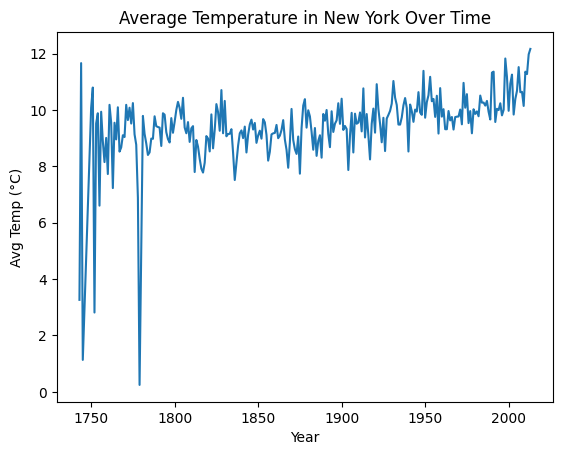

In [4]:
ny = df[df['City']=='New York']
ny_year = ny.groupby(ny['dt'].dt.year)['AvgTemp'].mean().reset_index(name='AvgTemp')
plt.figure()
plt.plot(ny_year['dt'], ny_year['AvgTemp'])
plt.title('Average Temperature in New York Over Time')
plt.xlabel('Year')
plt.ylabel('Avg Temp (°C)')
plt.show()


Temperatures in New York vary year to year, with a long-run warming trend in recent decades.

## Visualization 2: New York vs London Over Time

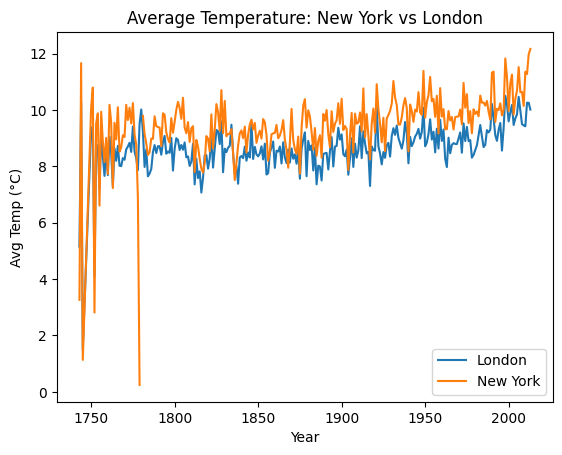

In [5]:
cities = df[df['City'].isin(['New York','London'])].copy()
cities['Year'] = cities['dt'].dt.year
cmp = cities.groupby(['Year','City'])['AvgTemp'].mean().reset_index()
wide = cmp.pivot(index='Year', columns='City', values='AvgTemp').reset_index()
plt.figure()
plt.plot(wide['Year'], wide['London'], label='London')
plt.plot(wide['Year'], wide['New York'], label='New York')
plt.title('Average Temperature: New York vs London')
plt.xlabel('Year')
plt.ylabel('Avg Temp (°C)')
plt.legend()
plt.show()


Both cities show upward trends over time; London remains milder on average than New York.

## Visualization 3: Global Temperature by Latitude

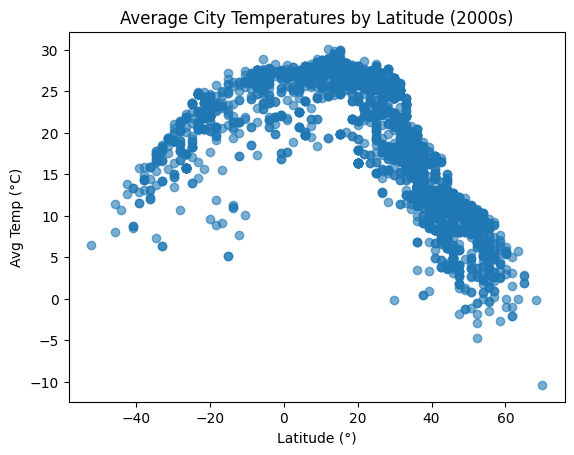

In [6]:
recent = df[df['dt'].dt.year >= 2000].copy()
recent['LatNum'] = recent['Latitude'].apply(lat_to_float)
avg_lat = recent.groupby(['City','LatNum'])['AvgTemp'].mean().reset_index()
plt.figure()
plt.scatter(avg_lat['LatNum'], avg_lat['AvgTemp'], alpha=0.6)
plt.title('Average City Temperatures by Latitude (2000s)')
plt.xlabel('Latitude (°)')
plt.ylabel('Avg Temp (°C)')
plt.show()


Cities near the equator are warmer on average, while cities at higher latitudes are cooler.